# 07 - Visualisation finale des résultats

Dans cette dernière étape, nous allons regrouper et visualiser les résultats obtenus dans les étapes précédentes. Nous allons afficher la trajectoire de l’objet, les graphes de vitesse et de direction, puis créer des visualisations finales qui peuvent être utilisées dans le rapport et la présentation.

Cette étape permet de présenter clairement le travail réalisé : initialisation de l’objet, suivi par Lucas-Kanade, extraction de la trajectoire, puis analyse du mouvement.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour charger les résultats, afficher les graphes, annoter les images et créer une vidéo finale simple.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

try:
    from src.visualization import (
        draw_bbox,
        draw_points,
        draw_trajectory,
        draw_current_center,
        save_frame,
        create_tracking_video,
    )
    print("Fonctions de visualisation importées depuis src.visualization.")
except ImportError:
    draw_bbox = None
    draw_points = None
    draw_trajectory = None
    draw_current_center = None
    save_frame = None
    create_tracking_video = None
    print("Import impossible : des fonctions simples seront définies dans le notebook.")


if draw_trajectory is None:
    def draw_trajectory(image, trajectory):
        output = image.copy()
        if trajectory is None or len(trajectory) == 0:
            return output

        trajectory_points = np.asarray(trajectory).reshape(-1, 2).astype(int)
        for index, point in enumerate(trajectory_points):
            x, y = point
            cv2.circle(output, (x, y), 3, (0, 0, 255), -1)
            if index > 0:
                prev_x, prev_y = trajectory_points[index - 1]
                cv2.line(output, (prev_x, prev_y), (x, y), (255, 0, 0), 2)
        return output


if draw_current_center is None:
    def draw_current_center(image, center):
        output = image.copy()
        if center is not None:
            x, y = [int(value) for value in center]
            cv2.circle(output, (x, y), 6, (0, 255, 255), -1)
        return output


if save_frame is None:
    def save_frame(image, output_path):
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        return cv2.imwrite(str(output_path), image)


if create_tracking_video is None:
    def create_tracking_video(image_files, trajectory_df, output_path, fps=20):
        if len(image_files) == 0 or len(trajectory_df) == 0:
            return False

        first_image = cv2.imread(str(image_files[0]))
        if first_image is None:
            return False

        height, width = first_image.shape[:2]
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
        if not writer.isOpened():
            return False

        trajectory = []
        written_frames = 0

        for _, row in trajectory_df.iterrows():
            frame_index = int(row["frame"])
            if frame_index < 0 or frame_index >= len(image_files):
                continue

            image = cv2.imread(str(image_files[frame_index]))
            if image is None:
                continue

            center = (row["x"], row["y"])
            trajectory.append(center)
            output = draw_trajectory(image, trajectory)
            output = draw_current_center(output, center)
            writer.write(output)
            written_frames += 1

        writer.release()
        return written_frames > 0

Fonctions de visualisation importées depuis src.visualization.


## 2. Définition des chemins

Nous définissons les chemins vers le dataset, les résultats, les graphes, les frames finales et la vidéo finale.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"

results_path = Path("../results")
plots_path = results_path / "plots"
frames_output_path = results_path / "frames_output"
videos_path = results_path / "videos"

trajectory_path = results_path / "trajectory.csv"
analysis_path = results_path / "motion_analysis.csv"

plots_path.mkdir(parents=True, exist_ok=True)
frames_output_path.mkdir(parents=True, exist_ok=True)
videos_path.mkdir(parents=True, exist_ok=True)

print("trajectory.csv existe :", trajectory_path.exists())
print("motion_analysis.csv existe :", analysis_path.exists())

image_extensions = [".jpg", ".png", ".jpeg"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []
    print("Attention : le dossier img est introuvable.")

print("Nombre total d'images dans le dataset :", len(image_files))

trajectory.csv existe : True
motion_analysis.csv existe : True
Nombre total d'images dans le dataset : 1661


## 3. Chargement des résultats

Nous chargeons la trajectoire et les résultats d’analyse obtenus dans les étapes précédentes.

In [3]:
trajectory_df = pd.DataFrame(columns=["frame", "x", "y", "tracked_points"])
analysis_df = pd.DataFrame()

if trajectory_path.exists():
    trajectory_df = pd.read_csv(trajectory_path)
    print("Aperçu de trajectory.csv :")
    display(trajectory_df.head())
else:
    print("trajectory.csv est introuvable.")

if analysis_path.exists():
    analysis_df = pd.read_csv(analysis_path)
    print("Aperçu de motion_analysis.csv :")
    display(analysis_df.head())
else:
    print("motion_analysis.csv est introuvable.")

print("Nombre de frames analysées :", len(trajectory_df))

Aperçu de trajectory.csv :


,frame,x,y,tracked_points
0,0,639.987488,337.962494,80
1,1,639.347351,337.929504,80
2,2,638.602051,337.767090,80
3,3,637.824585,337.649902,80
4,4,637.050232,337.471985,80


Aperçu de motion_analysis.csv :


,frame,x,y,tracked_points,dx,dy,distance,speed_px_per_frame,speed_px_per_second,direction_deg
0,0,639.987488,337.962494,80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,639.347351,337.929504,80,-0.640137,-0.032990,0.640986,0.640986,19.229586,-177.049867
2,2,638.602051,337.767090,80,-0.745300,-0.162415,0.762792,0.762792,22.883748,-167.706399
3,3,637.824585,337.649902,80,-0.777466,-0.117188,0.786248,0.786248,23.587442,-171.428328
4,4,637.050232,337.471985,80,-0.774353,-0.177917,0.794530,0.794530,23.835887,-167.060147


Nombre de frames analysées : 100


Nous chargeons ici les résultats produits dans les étapes précédentes. Ces fichiers contiennent la trajectoire de l’objet ainsi que les grandeurs calculées comme la vitesse et la direction.

## 4. Affichage de la trajectoire finale en 2D

Nous affichons la trajectoire finale dans le plan image. L’axe `y` est inversé pour respecter le repère des images.

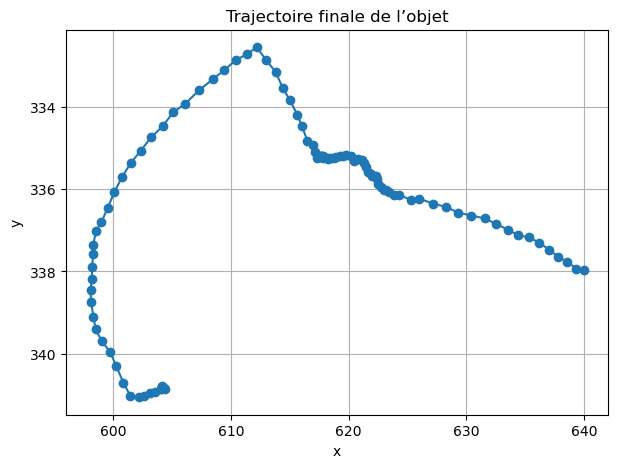

Graphe sauvegardé dans : ..\results\plots\final_trajectory_2d.png


In [4]:
final_trajectory_2d_path = plots_path / "final_trajectory_2d.png"

if len(trajectory_df) > 0:
    plt.figure(figsize=(7, 5))
    plt.plot(trajectory_df["x"], trajectory_df["y"], marker="o")
    plt.gca().invert_yaxis()
    plt.title("Trajectoire finale de l’objet")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.savefig(final_trajectory_2d_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", final_trajectory_2d_path)
else:
    print("Impossible de tracer la trajectoire car trajectory_df est vide.")

La trajectoire 2D montre le déplacement global de l’objet dans le plan image. Elle permet d’observer la direction générale du mouvement.

## 5. Affichage de la trajectoire sur une frame

Nous dessinons la trajectoire sur une frame de référence. Nous ajoutons aussi le point initial et le point final avec des couleurs différentes.

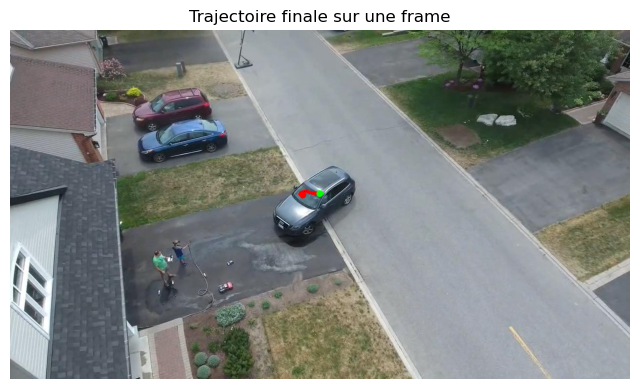

Image sauvegardée dans : ..\results\plots\final_trajectory_on_frame.png


In [5]:
final_trajectory_on_frame_path = plots_path / "final_trajectory_on_frame.png"

if len(trajectory_df) > 0 and len(image_files) > 0:
    reference_frame = int(trajectory_df["frame"].iloc[-1])
    reference_frame = min(reference_frame, len(image_files) - 1)
    reference_image = cv2.imread(str(image_files[reference_frame]))

    if reference_image is not None:
        trajectory_points = trajectory_df[["x", "y"]].values
        image_with_trajectory = draw_trajectory(reference_image, trajectory_points)

        initial_center = trajectory_points[0].astype(int)
        final_center = trajectory_points[-1].astype(int)
        cv2.circle(image_with_trajectory, tuple(initial_center), 7, (0, 255, 0), -1)
        cv2.circle(image_with_trajectory, tuple(final_center), 7, (0, 0, 255), -1)

        cv2.imwrite(str(final_trajectory_on_frame_path), image_with_trajectory)

        image_rgb = cv2.cvtColor(image_with_trajectory, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 5))
        plt.imshow(image_rgb)
        plt.title("Trajectoire finale sur une frame")
        plt.axis("off")
        plt.show()

        print("Image sauvegardée dans :", final_trajectory_on_frame_path)
    else:
        print("La frame de référence n'a pas pu être chargée.")
else:
    print("Impossible d'afficher la trajectoire sur une frame.")

Cette visualisation permet de vérifier que la trajectoire est cohérente avec la position réelle de l’objet dans la scène.

## 6. Affichage de la vitesse finale

Nous affichons la vitesse apparente de l’objet au cours du temps.

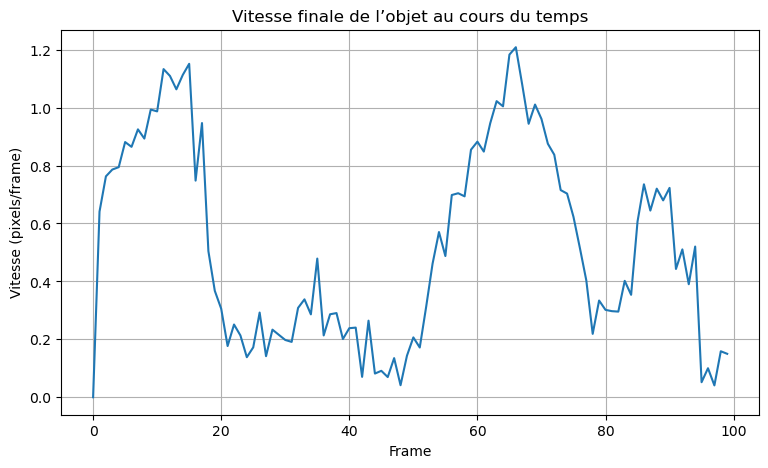

Graphe sauvegardé dans : ..\results\plots\final_speed_over_time.png


In [6]:
final_speed_plot_path = plots_path / "final_speed_over_time.png"

if len(analysis_df) > 0 and "speed_px_per_frame" in analysis_df.columns:
    plt.figure(figsize=(9, 5))
    plt.plot(analysis_df["frame"], analysis_df["speed_px_per_frame"])
    plt.title("Vitesse finale de l’objet au cours du temps")
    plt.xlabel("Frame")
    plt.ylabel("Vitesse (pixels/frame)")
    plt.grid(True)
    plt.savefig(final_speed_plot_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", final_speed_plot_path)
else:
    print("Impossible d'afficher la vitesse finale.")

La vitesse est exprimée en pixels par frame. Elle décrit le mouvement apparent de l’objet dans l’image, et non sa vitesse réelle en mètres par seconde.

## 7. Affichage de la direction finale

Nous affichons l’évolution de la direction du mouvement dans le plan image.

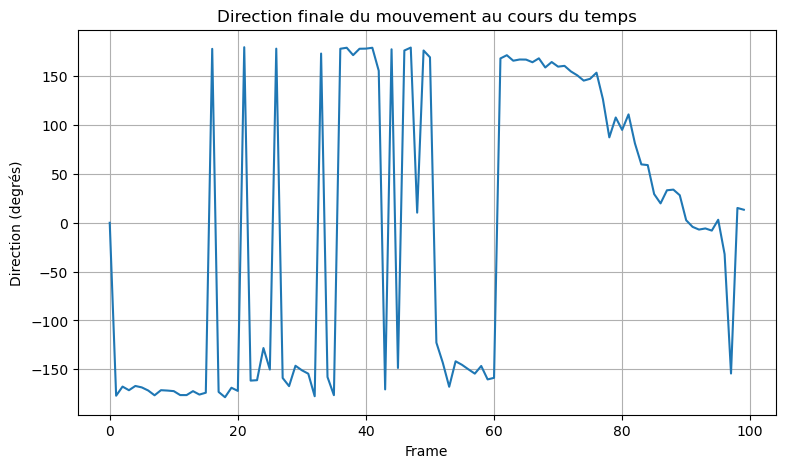

Graphe sauvegardé dans : ..\results\plots\final_direction_over_time.png


In [7]:
final_direction_plot_path = plots_path / "final_direction_over_time.png"

if len(analysis_df) > 0 and "direction_deg" in analysis_df.columns:
    plt.figure(figsize=(9, 5))
    plt.plot(analysis_df["frame"], analysis_df["direction_deg"])
    plt.title("Direction finale du mouvement au cours du temps")
    plt.xlabel("Frame")
    plt.ylabel("Direction (degrés)")
    plt.grid(True)
    plt.savefig(final_direction_plot_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", final_direction_plot_path)
else:
    print("Impossible d'afficher la direction finale.")

La direction permet de comprendre l’orientation du mouvement de l’objet dans le plan image. Les variations peuvent venir du mouvement réel de l’objet ou de petites instabilités du suivi.

## 8. Résumé numérique final

Nous calculons un résumé final pour présenter le mouvement estimé de manière quantitative.

In [8]:
if len(trajectory_df) > 0 and len(analysis_df) > 0:
    initial_position = (trajectory_df["x"].iloc[0], trajectory_df["y"].iloc[0])
    final_position = (trajectory_df["x"].iloc[-1], trajectory_df["y"].iloc[-1])

    total_dx = final_position[0] - initial_position[0]
    total_dy = final_position[1] - initial_position[1]
    total_distance = analysis_df["distance"].sum()
    mean_speed = analysis_df["speed_px_per_frame"].mean()
    max_speed = analysis_df["speed_px_per_frame"].max()
    mean_direction = analysis_df["direction_deg"].iloc[1:].mean()

    print("Résumé numérique final")
    print("-")
    print("Nombre de frames analysées :", len(trajectory_df))
    print("Position initiale :", initial_position)
    print("Position finale :", final_position)
    print("Déplacement horizontal total :", total_dx)
    print("Déplacement vertical total :", total_dy)
    print("Distance totale parcourue :", total_distance)
    print("Vitesse moyenne en pixels/frame :", mean_speed)
    print("Vitesse maximale en pixels/frame :", max_speed)
    print("Direction moyenne en degrés :", mean_direction)

    if total_dx > 0:
        print("Interprétation : l’objet se déplace globalement vers la droite.")
    elif total_dx < 0:
        print("Interprétation : l’objet se déplace globalement vers la gauche.")
    else:
        print("Interprétation : l’objet n’a pas de déplacement horizontal global marqué.")

    if total_dy > 0:
        print("Interprétation : l’objet descend globalement dans l’image.")
    elif total_dy < 0:
        print("Interprétation : l’objet monte globalement dans l’image.")
    else:
        print("Interprétation : l’objet n’a pas de déplacement vertical global marqué.")
else:
    print("Impossible de produire le résumé final car les résultats sont incomplets.")

Résumé numérique final
-
Nombre de frames analysées : 100
Position initiale : (np.float64(639.9874877929688), np.float64(337.9624938964844))
Position finale : (np.float64(604.4349365234375), np.float64(340.86376953125))
Déplacement horizontal total : -35.55255126953125
Déplacement vertical total : 2.901275634765625
Distance totale parcourue : 52.57668292175508
Vitesse moyenne en pixels/frame : 0.5257668292175508
Vitesse maximale en pixels/frame : 1.2087081106683153
Direction moyenne en degrés : -9.090631518917522
Interprétation : l’objet se déplace globalement vers la gauche.
Interprétation : l’objet descend globalement dans l’image.


Ce résumé donne une vision globale du mouvement estimé de l’objet. Il permet de présenter les résultats de manière quantitative.

## 9. Création de frames finales avec trajectoire

Nous créons quelques images finales montrant l’évolution progressive de la trajectoire. Ces images peuvent être utilisées dans le rapport ou dans la présentation.

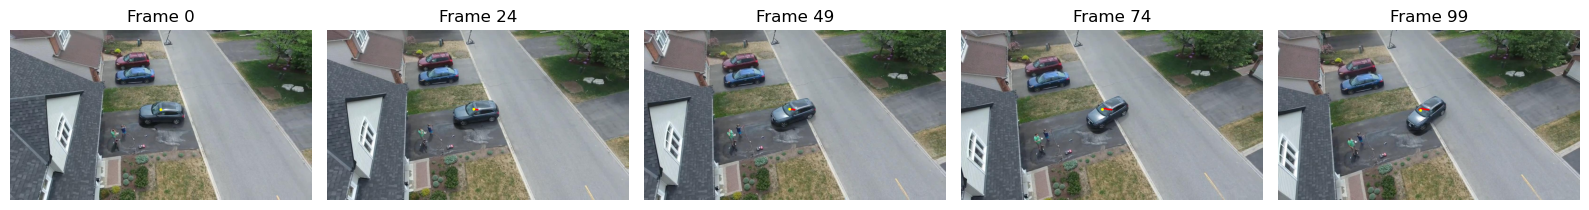

Frames sauvegardées dans : ..\results\frames_output


In [9]:
saved_examples = []

if len(trajectory_df) > 0 and len(image_files) > 0:
    selected_indices = np.linspace(0, len(trajectory_df) - 1, min(5, len(trajectory_df)), dtype=int)

    for output_index, row_index in enumerate(selected_indices):
        row = trajectory_df.iloc[row_index]
        frame_index = int(row["frame"])

        if frame_index < 0 or frame_index >= len(image_files):
            print(f"Frame {frame_index} ignorée car elle est hors du dataset.")
            continue

        image = cv2.imread(str(image_files[frame_index]))

        if image is None:
            print(f"Frame {frame_index} non chargée.")
            continue

        partial_trajectory = trajectory_df.iloc[:row_index + 1][["x", "y"]].values
        center = (row["x"], row["y"])

        output_image = draw_trajectory(image, partial_trajectory)
        output_image = draw_current_center(output_image, center)

        output_path = frames_output_path / f"frame_result_{output_index:03d}.png"
        save_frame(output_image, output_path)

        output_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)
        saved_examples.append((frame_index, output_rgb, output_path))

    if len(saved_examples) > 0:
        fig, axes = plt.subplots(1, len(saved_examples), figsize=(16, 4))
        if len(saved_examples) == 1:
            axes = [axes]

        for axis, (frame_index, image_rgb, output_path) in zip(axes, saved_examples):
            axis.imshow(image_rgb)
            axis.set_title(f"Frame {frame_index}")
            axis.axis("off")

        plt.tight_layout()
        plt.show()

        print("Frames sauvegardées dans :", frames_output_path)
else:
    print("Impossible de créer les frames finales car les données manquent.")

Ces images montrent l’évolution de la trajectoire au cours du temps. Elles sont utiles pour illustrer le suivi dans le rapport ou la présentation.

## 10. Création d’une vidéo finale simple

Nous créons une vidéo finale avec OpenCV. La trajectoire est dessinée progressivement sur les frames analysées.

In [10]:
video_output_path = videos_path / "final_tracking_video.mp4"
fps = 20

try:
    video_created = create_tracking_video(image_files, trajectory_df, video_output_path, fps=fps)

    if video_created:
        print("Vidéo finale sauvegardée dans :", video_output_path)
    else:
        print("La vidéo n'a pas pu être créée. Vérifier les images et la trajectoire.")
except Exception as error:
    print("La vidéo n'a pas pu être créée.")
    print("Erreur :", error)

Vidéo finale sauvegardée dans : ..\results\videos\final_tracking_video.mp4


La vidéo finale permet de visualiser le mouvement de l’objet et l’évolution de sa trajectoire dans la séquence.

## 11. Synthèse des résultats

Les résultats montrent que l’objet a été suivi sur plusieurs frames à l’aide de la méthode de Lucas-Kanade. La trajectoire extraite représente le déplacement global de l’objet dans le plan image. L’analyse de la vitesse et de la direction permet de décrire quantitativement ce mouvement. Les résultats restent exprimés en pixels, car aucune calibration de caméra n’a été effectuée.

Nous retenons aussi plusieurs limites :

- le suivi dépend de la qualité des points caractéristiques ;
- les occlusions peuvent perturber le suivi ;
- la vitesse est une vitesse apparente en pixels, pas une vitesse réelle ;
- la méthode Lucas-Kanade suppose des petits déplacements et une illumination presque constante.

## 12. Conclusion finale du projet

Dans ce projet, nous avons étudié l’estimation du mouvement d’un objet unique dans une séquence d’images. Nous avons d’abord exploré le dataset, puis prétraité les images. Ensuite, nous avons initialisé l’objet à suivre à partir de sa bounding box et détecté des points caractéristiques dans sa région d’intérêt. Nous avons appliqué Lucas-Kanade pour suivre ces points entre les frames, puis extrait la trajectoire globale de l’objet. Enfin, nous avons analysé la vitesse et la direction du mouvement. Ce projet nous a permis de comprendre les principes de base du flot optique et les hypothèses nécessaires à l’estimation du mouvement.